In [7]:
import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from libpysal.weights import DistanceBand, lag_spatial
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
g  = gpd.read_file("../Data/Shapefiles/APES_metric.gpkg", layer="nuts3")
g = g.loc[(~g.geometry.is_empty) & (g["RecordType"] != "ZIKV")].copy()

In [3]:
avg_var = ["Forest", "Shrub", "Urban", "Crop", "Water", "Other",
           "Mean_P_Winter", "Max_WD_Winter", "Max_DD_Winter",
           "Mean_T_Spring", "Max_DD_Spring",
           "Mean_T_Summer",
           "Max_WD_Autumn", "Max_DD_Autumn",
           "gdp", "pop_dens"]

cols_keep = (["incidence"] + avg_var +
             ["geometry", "NUTS_NAME", "NUTS_CODE"])

df = g[cols_keep].copy()
agg_dict = {"incidence": "sum"}
agg_dict.update({v: "mean" for v in avg_var})
agg_dict.update({"geometry": "first", "NUTS_NAME": "first"})

fin = (
    df.groupby("NUTS_CODE", as_index=False)
      .agg(agg_dict)
      .set_geometry("geometry")
)
fin = gpd.GeoDataFrame(fin, geometry="geometry", crs=g.crs)
fin["cent"] = fin.geometry.centroid

Q:\UserTemp\massaro\AppData\Local\Temp\272\ipykernel_17944\1829038815.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fin["cent"] = fin.geometry.centroid


In [4]:
fin_m = fin.to_crs(32633)
coords = np.column_stack([fin_m.geometry.centroid.x, fin_m.geometry.centroid.y])

In [6]:

# 4) Create flat DataFrame for statsmodels (same as your OLS)
def fmt_p(p):
    try:
        return "<.001" if p < 0.001 else f"{p:.3f}"
    except Exception:
        return str(p)
# --- prepare standardized Xs ---
tmp = fin_m.copy()
X_thr = pd.DataFrame(tmp.drop(columns=[c for c in ["geometry", "cent"] if c in tmp.columns]))

design_cols = avg_var + ["gdp", "pop_dens"]


# --- model formula ---
formula = (
    "Y_weighted ~ Forest + Shrub + Urban + Crop + Water + Other + "
    "Mean_P_Winter + Max_WD_Winter + Max_DD_Winter + "
    "Mean_T_Spring + Max_DD_Spring + "
    "Max_WD_Autumn + Max_DD_Autumn + gdp + pop_dens"
)

# --- loop thresholds ---
thresholds = np.arange(100_000, 200_000 + 1, 10_000)

In [17]:
from esda.moran import Moran

In [32]:
scaler = StandardScaler()
X_thr_z = X_thr.copy()
X_thr_z[design_cols] = scaler.fit_transform(X_thr[design_cols])
y_vec = fin_m["incidence"].to_numpy()  # can be raw; Wy will be z-scored later

metrics = []
for thr in thresholds:
    W = DistanceBand(coords, threshold=thr, binary=True, silence_warnings=True)
    W.transform = "R"  # row-standardize

    # spatial lag and z-score
    y_lag = lag_spatial(W, y_vec)
    y_lag_z = (y_lag - y_lag.mean()) / y_lag.std(ddof=0)
    #scaler = StandardScaler()
    #y_lag_z = scaler.fit_transform(y_lag.reshape(-1, 1))

    # assemble data for OLS
    XY_models = X_thr_z.copy()
    XY_models["Y_weighted"] = y_lag_z

    lm_fit_thr = smf.ols(formula, data=XY_models).fit()

    # optional: print results
    print(f"\n=== Distance threshold = {thr/1000:.0f} km (row-std W; z-scored Wy) ===")
    print(lm_fit_thr.summary().tables[1])

    # 3) Assemble a temp DF with ALL rows
    tmp = fin_m.copy()
    tmp["Y_weighted"] = y_lag_z

    # 4) Build a CLEAN mask: only rows with complete data for model
    needed = ["Y_weighted"] + design_cols
    mask = tmp[needed].notna().all(axis=1).to_numpy()

    # If nothing to fit, skip
    if mask.sum() == 0:
        print(f"[WARN] {thr/1000:.0f} km → no complete cases. Skipping.")
        continue

    # 5) Subset DF and COORDS and W to the SAME rows
    tmp_clean = tmp.loc[mask].copy()
    coords_clean = coords[mask]
    # Diagnostics about network structure
    n_islands = len(getattr(W_sub, "islands", []))
    mean_neighbors = float(np.mean([len(nbrs) for nbrs in W_sub.neighbors.values()]))
    # Rebuild W on the subset (simplest & safest)
    W_sub = DistanceBand(coords_clean, threshold=thr, binary=True, silence_warnings=True)
    W_sub.transform = "R"
    
    # 7) Residual Moran’s I (dimensions now match)
    resid = lm_fit_thr.resid.values  # length == W_sub.n
    mi = Moran(resid,W_sub)  # permutations=999 by default

    metrics.append({
        "threshold_m": thr,
        "threshold_km": thr / 1000,
        "r2": lm_fit_thr.rsquared,
        "adj_r2": lm_fit_thr.rsquared_adj,
        "aic": lm_fit_thr.aic,
        "bic": lm_fit_thr.bic,
        "moran_I": mi.I,
        "moran_p": mi.p_sim,
        "n_obs": int(mask.sum()),
        "n_islands": n_islands,
        "mean_neighbors": mean_neighbors
    })

# ----------------------------
# Save metrics and quick plots
# ----------------------------
m = pd.DataFrame(metrics)


=== Distance threshold = 100 km (row-std W; z-scored Wy) ===
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0085      0.027      0.317      0.751      -0.044       0.061
Forest           -0.1102      0.037     -2.968      0.003      -0.183      -0.037
Shrub             0.2335      0.032      7.407      0.000       0.172       0.295
Urban             0.0024      0.029      0.082      0.935      -0.054       0.059
Crop             -0.0860      0.037     -2.348      0.019      -0.158      -0.014
Water             0.1102      0.029      3.756      0.000       0.053       0.168
Other             0.0124      0.032      0.383      0.702      -0.051       0.076
Mean_P_Winter     0.1011      0.043      2.351      0.019       0.017       0.185
Max_WD_Winter    -0.0721      0.057     -1.267      0.205      -0.184       0.039
Max_DD_Winter    -0.0410      0.044 

In [28]:
import pylab as plt
def _plot(x, y, ylabel, title, fname):
    out_dir = '../Figures/'
    plt.subplots()
    plt.plot(m[x], m[y], marker="o")
    plt.xlabel("Distance threshold (km)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

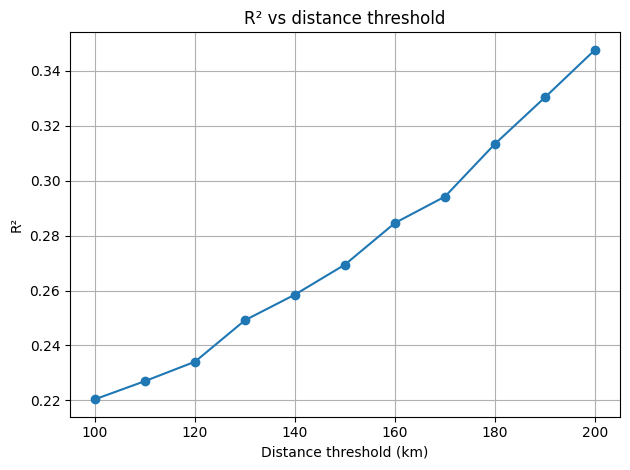

In [29]:
_plot("threshold_km", "r2", "R²", "R² vs distance threshold", "r2_vs_threshold.png")

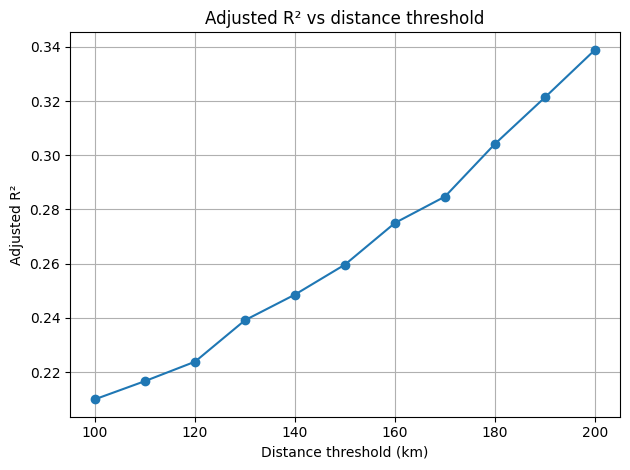

In [30]:
_plot("threshold_km", "adj_r2", "Adjusted R²", "Adjusted R² vs distance threshold", "adjr2_vs_threshold.png")

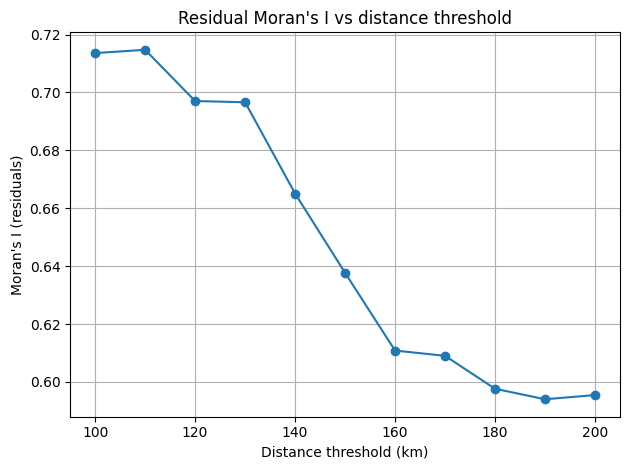

In [31]:
_plot("threshold_km", "moran_I", "Moran's I (residuals)", "Residual Moran's I vs distance threshold", "moranI_vs_threshold.png")

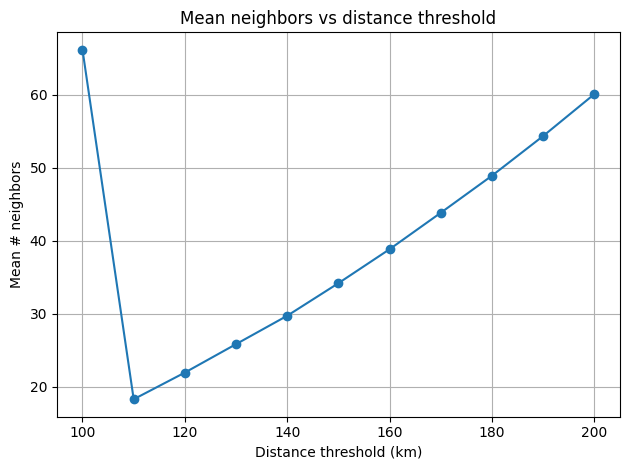

In [33]:
_plot("threshold_km", "mean_neighbors", "Mean # neighbors", "Mean neighbors vs distance threshold", "mean_neighbors_vs_threshold.png")

In [34]:
if not m.empty:
    best_aic_row = m.loc[m["aic"].idxmin()]
    best_moran_row = m.iloc[(m["moran_I"].abs()).idxmin()]
    print("\n=== Summary ===")
    print("Best (min) AIC at ~{:.0f} km: AIC={:.2f}, R²={:.3f}, adj R²={:.3f}, Moran's I={:.3f} (p={:.3f})"
          .format(best_aic_row["threshold_km"], best_aic_row["aic"], best_aic_row["r2"],
                  best_aic_row["adj_r2"], best_aic_row["moran_I"], best_aic_row["moran_p"]))
    print("Smallest |Moran's I| at ~{:.0f} km: I={:.3f} (p={:.3f}), AIC={:.2f}, adj R²={:.3f}, n_obs={}"
          .format(best_moran_row["threshold_km"], best_moran_row["moran_I"],
                  best_moran_row["moran_p"], best_moran_row["aic"], best_moran_row["adj_r2"],
                  int(best_moran_row["n_obs"])))


=== Summary ===
Best (min) AIC at ~200 km: AIC=2798.18, R²=0.348, adj R²=0.339, Moran's I=0.595 (p=0.001)
Smallest |Moran's I| at ~190 km: I=0.594 (p=0.001), AIC=2827.91, adj R²=0.321, n_obs=1134


In [49]:
design_cols = avg_var

In [50]:
from libpysal.weights import DistanceBand, lag_spatial
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
from esda import Moran
import numpy as np
import pandas as pd

# assume you already have:
# fin_m, coords (UTM meters), design_cols, formula, thresholds
# X_thr_z : standardized predictors (same columns as design_cols)
# y_vec   : raw incidence as a 1D array (fin_m["incidence"].to_numpy())

metrics = []
gwr_rows = []

for thr in thresholds:
    # 1) Row-standardized W and spatial lag (neighbor average)
    W = DistanceBand(coords, threshold=thr, binary=True, silence_warnings=True)
    W.transform = "R"

    # 2) Wy and z-score AFTER lag (this is your OLS y)
    y_lag = lag_spatial(W, y_vec)
    y_lag_z = (y_lag - y_lag.mean()) / y_lag.std(ddof=0)

    # 3) OLS with SAME X and y as before
    XY_models = X_thr_z.copy()
    XY_models["Y_weighted"] = y_lag_z
    lm_fit_thr = smf.ols(formula, data=XY_models).fit()

    print(f"\n=== Distance threshold = {thr/1000:.0f} km (row-std W; z-scored Wy) ===")
    print(lm_fit_thr.summary().tables[1])

    # 4) Clean mask for complete cases (same mask for OLS/GWR/Moran)
    tmp = fin_m.copy()
    tmp["Y_weighted"] = y_lag_z
    needed = ["Y_weighted"] + design_cols
    mask = tmp[needed].notna().all(axis=1).to_numpy()
    if mask.sum() == 0:
        print(f"[WARN] {thr/1000:.0f} km → no complete cases. Skipping.")
        continue

    # 5) Subset coords and rebuild W on subset (dimensions must match)
    coords_clean = coords[mask]
    W_sub = DistanceBand(coords_clean, threshold=thr, binary=True, silence_warnings=True)
    W_sub.transform = "R"

    # Diagnostics about network structure (optional)
    degs = np.asarray(W_sub.sparse.sum(axis=1)).ravel()
    n_islands = int((degs == 0).sum())
    mean_neighbors = float(degs.mean())

    # 6) Moran’s I on OLS residuals (optional)
    try:
        resid = lm_fit_thr.resid.values[mask]  # align to subset length
        mi = Moran(resid, W_sub)               # permutations=999 by default
        moran_I, moran_p = mi.I, mi.p_sim
    except Exception as e:
        moran_I, moran_p = np.nan, np.nan
        print(f"[Moran WARN] {thr/1000:.0f} km → {e}")

    # 7) === GWR with the SAME y and X as OLS ===
    #    Use exponential kernel, adaptive bandwidth
    y_gwr = XY_models.loc[mask, "Y_weighted"].to_numpy().reshape(-1, 1)       # same y as OLS
    X_gwr = XY_models.loc[mask, design_cols].to_numpy()                        # same X as OLS

    # safe minimum bandwidth (avoid tiny local windows → negative/inf R²)
    n, k = X_gwr.shape
    bw_min = max(k + 1 + 5, 30)       # params + cushion; at least ~30 neighbors
    bw_min = min(bw_min, n - 1)

    try:
        bw = Sel_BW(coords_clean, y_gwr, X_gwr, kernel="exponential", fixed=False).search(bw_min=bw_min)
        if isinstance(bw, (int, float)) and bw < bw_min:
            bw = bw_min

        gwr_fit = GWR(coords_clean, y_gwr, X_gwr, bw,
                      kernel="exponential", fixed=False, constant=True).fit()

        # AICc / local R²
        aicc = getattr(gwr_fit, "aicc", getattr(gwr_fit, "AICc", np.nan))
        r2_mu = float(gwr_fit.localR2.mean()) if hasattr(gwr_fit, "localR2") else np.nan
        r2_lo = float(gwr_fit.localR2.min())  if hasattr(gwr_fit, "localR2") else np.nan
        r2_hi = float(gwr_fit.localR2.max())  if hasattr(gwr_fit, "localR2") else np.nan

        print(f"GWR(exp) → bw={int(bw)} | AICc={aicc if np.isfinite(aicc) else 'NA'} | "
              f"localR2 μ/lo/hi={r2_mu:.3f}/{r2_lo:.3f}/{r2_hi:.3f} | n={n}")

        gwr_rows.append({
            "threshold_m": thr,
            "threshold_km": thr/1000,
            "kernel": "exponential",
            "bw_neighbors": int(bw),
            "AICc": aicc,
            "mean_localR2": r2_mu,
            "min_localR2": r2_lo,
            "max_localR2": r2_hi,
            "n": n,
            "n_islands": n_islands,
            "mean_neighbors": mean_neighbors
        })
    except Exception as e:
        print(f"GWR(exp) ERROR @ {thr/1000:.0f} km: {e}")
        gwr_rows.append({
            "threshold_m": thr,
            "threshold_km": thr/1000,
            "kernel": "exponential",
            "bw_neighbors": np.nan,
            "AICc": np.nan,
            "mean_localR2": np.nan,
            "min_localR2": np.nan,
            "max_localR2": np.nan,
            "n": int(mask.sum()),
            "n_islands": n_islands,
            "mean_neighbors": mean_neighbors,
            "error": str(e)
        })

    # Collect OLS metrics too
    metrics.append({
        "threshold_m": thr,
        "threshold_km": thr / 1000,
        "r2": lm_fit_thr.rsquared,
        "adj_r2": lm_fit_thr.rsquared_adj,
        "aic": lm_fit_thr.aic,
        "bic": lm_fit_thr.bic,
        "moran_I": moran_I,
        "moran_p": moran_p,
        "n_obs": int(mask.sum()),
        "n_islands": n_islands,
        "mean_neighbors": mean_neighbors
    })

# Final dataframes
ols_df = pd.DataFrame(metrics)
gwr_df = pd.DataFrame(gwr_rows)



=== Distance threshold = 100 km (row-std W; z-scored Wy) ===
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0085      0.027      0.317      0.751      -0.044       0.061
Forest           -0.1102      0.037     -2.968      0.003      -0.183      -0.037
Shrub             0.2335      0.032      7.407      0.000       0.172       0.295
Urban             0.0024      0.029      0.082      0.935      -0.054       0.059
Crop             -0.0860      0.037     -2.348      0.019      -0.158      -0.014
Water             0.1102      0.029      3.756      0.000       0.053       0.168
Other             0.0124      0.032      0.383      0.702      -0.051       0.076
Mean_P_Winter     0.1011      0.043      2.351      0.019       0.017       0.185
Max_WD_Winter    -0.0721      0.057     -1.267      0.205      -0.184       0.039
Max_DD_Winter    -0.0410      0.044 

KeyboardInterrupt: 

In [43]:
design_cols = avg_var
design_cols

['Forest',
 'Shrub',
 'Urban',
 'Crop',
 'Water',
 'Other',
 'Mean_P_Winter',
 'Max_WD_Winter',
 'Max_DD_Winter',
 'Mean_T_Spring',
 'Max_DD_Spring',
 'Mean_T_Summer',
 'Max_WD_Autumn',
 'Max_DD_Autumn',
 'gdp',
 'pop_dens']

In [51]:
# coords: your array of shape (n,2) in meters (UTM)
coords = coords.astype(float)

# (optional) tiny jitter if exact duplicates
if np.unique(coords, axis=0).shape[0] < coords.shape[0]:
    rng = np.random.default_rng(42)
    coords = coords + rng.normal(0.0, 1e-6, size=coords.shape)

gwr_rows = []

for thr in thresholds:
    # --- you already have these from your loop ---
    # W.transform = "R"  # you set this earlier
    # y_lag = lag_spatial(W, y_vec)
    # y_lag_z = (y_lag - y_lag.mean()) / y_lag.std(ddof=0)
    # XY_models = X_thr_z.copy(); XY_models["Y_weighted"] = y_lag_z

    # clean mask aligned with your OLS
    tmp = fin_m.copy()
    tmp["Y_weighted"] = y_lag_z
    needed = ["Y_weighted"] + design_cols
    mask = tmp[needed].notna().all(axis=1).to_numpy()
    if mask.sum() == 0:
        print(f"[WARN] {thr/1000:.0f} km → no complete cases. Skipping GWR.")
        continue

    coords_clean = coords[mask]
    y_gwr = XY_models.loc[mask, "Y_weighted"].to_numpy().reshape(-1, 1)     # SAME y as OLS
    X_gwr = XY_models.loc[mask, design_cols].to_numpy()                      # SAME X as OLS
    n, k = X_gwr.shape

    # (optional) drop near-zero-variance columns in the masked subset
    var_ok = X_gwr.std(axis=0, ddof=0) > 1e-8
    if not var_ok.all():
        kept = np.array(design_cols)[var_ok]
        dropped = list(np.array(design_cols)[~var_ok])
        if dropped:
            print(f"[INFO] {thr/1000:.0f} km → dropping near-zero variance cols: {dropped}")
        X_gwr = X_gwr[:, var_ok]
        k = X_gwr.shape[1]

    # Robust minimum bandwidth (adaptive = neighbour count)
    bw_min = max(k + 10, 80)     # ensure ample neighbours; adjust upward if needed
    bw_min = min(bw_min, n - 1)

    # Try fit; on singular, retry with larger bw
    for_attempt = [
        ("primary", bw_min),
        ("retry", min(max(int(1.25 * bw_min), bw_min + 10), n - 1))
    ]

    fit = None
    last_err = None
    for tag, bw_floor in for_attempt:
        try:
            bw = Sel_BW(coords_clean, y_gwr, X_gwr,
                        kernel="exponential", fixed=False).search(bw_min=bw_floor)
            if isinstance(bw, (int, float)) and bw < bw_floor:
                bw = bw_floor

            fit = GWR(coords_clean, y_gwr, X_gwr, bw,
                      kernel="exponential", fixed=False, constant=True).fit()
            break
        except Exception as e:
            last_err = e
            if tag == "retry":
                print(f"GWR(exp) ERROR @ {thr/1000:.0f} km even after retry: {e}")

    if fit is None:
        gwr_rows.append({
            "threshold_m": thr, "threshold_km": thr/1000, "kernel": "exponential",
            "bw_neighbors": np.nan, "AICc": np.nan,
            "mean_localR2": np.nan, "min_localR2": np.nan, "max_localR2": np.nan,
            "n": int(n), "error": str(last_err)
        })
        continue

    # Summaries
    aicc = getattr(fit, "aicc", getattr(fit, "AICc", np.nan))
    r2_mu = float(fit.localR2.mean()) if hasattr(fit, "localR2") else np.nan
    r2_lo = float(fit.localR2.min())  if hasattr(fit, "localR2") else np.nan
    r2_hi = float(fit.localR2.max())  if hasattr(fit, "localR2") else np.nan

    print(f"GWR(exp) @ {thr/1000:.0f} km → bw={int(bw)} | "
          f"AICc={aicc if np.isfinite(aicc) else 'NA'} | "
          f"localR2 μ/lo/hi={r2_mu:.3f}/{r2_lo:.3f}/{r2_hi:.3f} | n={n}")

    gwr_rows.append({
        "threshold_m": thr, "threshold_km": thr/1000, "kernel": "exponential",
        "bw_neighbors": int(bw), "AICc": aicc,
        "mean_localR2": r2_mu, "min_localR2": r2_lo, "max_localR2": r2_hi,
        "n": int(n)
    })

GWR(exp) @ 100 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 110 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 120 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 130 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 140 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 150 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 160 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 170 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 180 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 190 km → bw=81 | AICc=1994.32981097641 | localR2 μ/lo/hi=0.694/0.503/0.817 | n=1134
GWR(exp) @ 200 km → bw=81 | AICc=1994.32981097641 

In [56]:
tmp = fin_m.dropna().reset_index()
tmp['localr2']= fit.localR2

<Axes: >

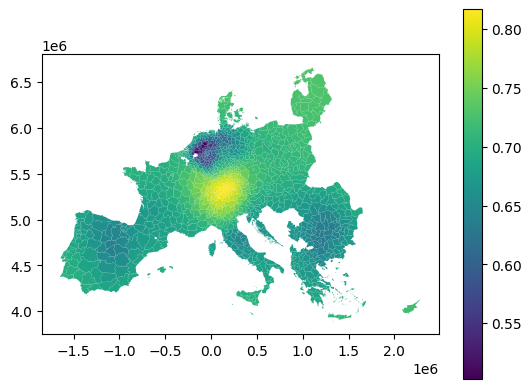

In [58]:
tmp.plot(column='localr2', legend=True)

In [125]:
needed = ["incidence"] + design_cols + ['geometry']
gdf_ok = fin_m[needed].dropna().reset_index(drop=True)
gdf_ok.head()

,incidence,Forest,Shrub,Urban,Crop,Water,Other,Mean_P_Winter,Max_WD_Winter,Max_DD_Winter,Mean_T_Spring,Max_DD_Spring,Mean_T_Summer,Max_WD_Autumn,Max_DD_Autumn,gdp,pop_dens,geometry
0,0.000000,29792.285714,2233.142857,1685.000000,23692.857143,684.214286,10276.500000,0.004791,9.928571,10.428571,13.171619,7.857143,18.335533,8.000000,14.000000,2950.000000,3.422594,"MULTIPOLYGON (((959466.125 4647785.256, 957657..."
1,0.000000,2486.428571,167.142857,734.571429,7191.714286,111.000000,56.142857,0.004986,9.500000,11.500000,17.356366,14.428571,22.507814,7.428571,14.500000,3983.333333,24.474320,"MULTIPOLYGON (((901786.325 4612638.053, 900823..."
2,0.000000,12931.857143,681.928571,595.428571,8346.642857,360.214286,400.928571,0.004907,9.142857,10.857143,15.655724,11.642857,20.888817,7.714286,14.500000,2933.333333,5.199612,"MULTIPOLYGON (((931103.131 4665312.244, 930901..."
3,0.000073,24933.115385,1751.884615,1694.615385,15066.115385,2997.346154,3380.923077,0.008831,10.923077,10.384615,16.720644,9.307692,21.268971,7.307692,14.346154,3020.000000,3.927460,"MULTIPOLYGON (((895277.491 4713536.256, 893963..."
4,0.000000,40329.357143,2462.285714,1559.285714,44483.571429,238.571429,6374.928571,0.003791,8.285714,11.000000,14.318813,10.285714,19.805333,6.857143,15.500000,2816.666667,5.741390,"MULTIPOLYGON (((959579.623 4588412.508, 959183..."


In [126]:
len(gdf_ok)

1134

In [129]:
# clean mask aligned with your OLS
thr = 150000
tmp = gdf_ok.copy()

coords = np.column_stack([tmp.geometry.centroid.x, tmp.geometry.centroid.y])
y_vec = tmp['incidence'].to_numpy()  # can be raw; Wy will be z-scored later
W = DistanceBand(coords, threshold=thr, binary=True, silence_warnings=True)
W.transform = "R"

# 2) Wy and z-score AFTER lag (this is your OLS y)
y_lag = lag_spatial(W, y_vec)
y_lag_z = (y_lag - y_lag.mean()) / y_lag.std(ddof=0)

scaler = StandardScaler()
tmp[design_cols] = scaler.fit_transform(tmp[design_cols])
XY_models = tmp.copy()
XY_models["Y_weighted"] = y_lag_z

y_gwr = XY_models["Y_weighted"].to_numpy().reshape(-1, 1)     # SAME y as OLS
X_gwr = XY_models[design_cols].to_numpy()                      # SAME X as OLS


In [116]:
bw = Sel_BW(coords, y_gwr, X_gwr, kernel="gaussian", fixed=False).search()
gwr_fit = GWR(coords, y_gwr, X_gwr, bw, kernel="gaussian", fixed=False, constant=True).fit()
gwr_fit.localR2

array([[0.6270114 ],
       [0.63166887],
       [0.62922362],
       ...,
       [0.60540033],
       [0.61373211],
       [0.60377537]])

<Axes: >

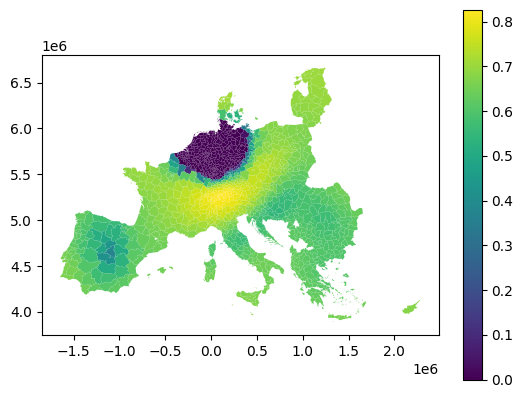

In [117]:
gdf_ok['localr2'] = gwr_fit.localR2
gdf_ok.plot(column='localr2', legend=True, vmin=0)

In [118]:
bw = Sel_BW(coords, y_gwr, X_gwr, kernel="exponential", fixed=False).search()
gwr_fit = GWR(coords, y_gwr, X_gwr, bw, kernel="exponential", fixed=False, constant=True).fit()
gwr_fit.localR2

array([[0.67674045],
       [0.6797923 ],
       [0.67672893],
       ...,
       [0.68792805],
       [0.6937689 ],
       [0.68951347]])

<Axes: >

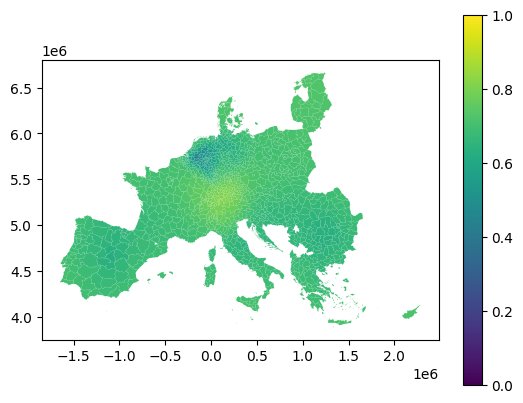

In [120]:
gdf_ok['localr2'] = gwr_fit.localR2
gdf_ok.plot(column='localr2', legend=True, vmin=0, vmax=1)

In [137]:
bw

70

In [130]:
from spreg import OLS  # pip install pysal spreg

# --- reuse your prepared data ---
# X_thr_z: DataFrame with standardized predictors (columns = design_cols)
# y_lag_z: 1D array, Wy z-scored AFTER lag (your OLS dependent variable)
# design_cols: list of predictor names

y = y_lag_z.reshape(-1, 1)                 # (n,1)
X = XY_models[design_cols].to_numpy()        # (n,k)

# add intercept explicitly (spreg can work without, but it’s clearer this way)
X = np.hstack([np.ones((X.shape[0], 1)), X])
name_x = ['const'] + design_cols

ols = OLS(y, X, name_y="Y_weighted", name_x=name_x, nonspat_diag=True)  # global diagnostics
# quick peek
print("R2:", ols.r2)
print("Adj R2:", ols.ar2)
print("AIC:", ols.aic)
print("BIC:", ols.schwarz)
# Coeff table
coefs = pd.DataFrame({
    "term": name_x,
    "beta": ols.betas.ravel(),
    "t": [t[0] for t in ols.t_stat],
    "p": [t[1] for t in ols.t_stat]
})
print(coefs)

R2: 0.3350438024914447
Adj R2: 0.32551891515023
AIC: 2789.441913811187
BIC: 2875.0115240440778
             term          beta             t             p
0           const  6.372103e-16  2.611637e-14  1.000000e+00
1          Forest -1.122819e-01 -3.302229e+00  9.895720e-04
2           Shrub  1.925127e-01  6.798432e+00  1.718463e-11
3           Urban -1.606792e-03 -6.011348e-02  9.520760e-01
4            Crop -1.200893e-01 -3.557264e+00  3.904471e-04
5           Water  8.525085e-02  3.137961e+00  1.745816e-03
6           Other -1.222307e-03 -4.086888e-02  9.674077e-01
7   Mean_P_Winter -8.935600e-02 -2.004520e+00  4.525543e-02
8   Max_WD_Winter  1.649441e-02  3.149959e-01  7.528236e-01
9   Max_DD_Winter -1.436306e-01 -3.471701e+00  5.369425e-04
10  Mean_T_Spring -9.102172e-01 -7.391424e+00  2.840806e-13
11  Max_DD_Spring -4.877211e-01 -1.228248e+01  1.287483e-32
12  Mean_T_Summer  1.533990e+00  1.070502e+01  1.587199e-25
13  Max_WD_Autumn  2.979344e-02  6.946783e-01  4.874014e-01
14  M

In [131]:
print(coefs.round(3))


             term   beta       t      p
0           const  0.000   0.000  1.000
1          Forest -0.112  -3.302  0.001
2           Shrub  0.193   6.798  0.000
3           Urban -0.002  -0.060  0.952
4            Crop -0.120  -3.557  0.000
5           Water  0.085   3.138  0.002
6           Other -0.001  -0.041  0.967
7   Mean_P_Winter -0.089  -2.005  0.045
8   Max_WD_Winter  0.016   0.315  0.753
9   Max_DD_Winter -0.144  -3.472  0.001
10  Mean_T_Spring -0.910  -7.391  0.000
11  Max_DD_Spring -0.488 -12.282  0.000
12  Mean_T_Summer  1.534  10.705  0.000
13  Max_WD_Autumn  0.030   0.695  0.487
14  Max_DD_Autumn  0.100   2.274  0.023
15            gdp -0.067  -2.044  0.041
16       pop_dens  0.040   1.455  0.146


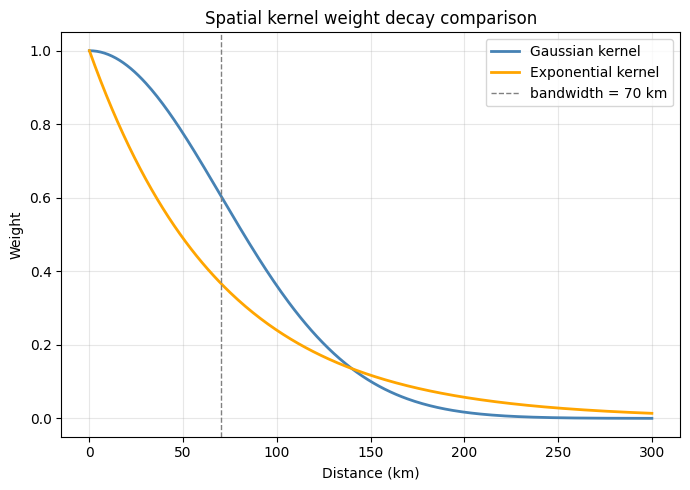

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# --- Imposta un range di distanze (in km per leggibilità)
d = np.linspace(0, 300, 300)  # 0–300 km
bw = 70  # bandwidth (in km)

# --- Calcola i pesi per ciascun kernel
w_gauss = np.exp(-0.5 * (d / bw) ** 2)
w_exp = np.exp(-d / bw)

# --- Plot di confronto
plt.figure(figsize=(7, 5))
plt.plot(d, w_gauss, label="Gaussian kernel", lw=2, color="steelblue")
plt.plot(d, w_exp, label="Exponential kernel", lw=2, color="orange")
plt.axvline(bw, color="gray", ls="--", lw=1, label=f"bandwidth = {bw} km")

plt.xlabel("Distance (km)")
plt.ylabel("Weight")
plt.title("Spatial kernel weight decay comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [138]:
def get_aicc_safe(fit):
    # Try common names across mgwr versions
    for name in ("aicc", "AICc", "aic_c"):
        if hasattr(fit, name):
            try:
                return float(getattr(fit, name))
            except Exception:
                pass
    # Fallback to AIC if nothing else exists
    if hasattr(fit, "aic"):
        try:
            return float(getattr(fit, "aic"))
        except Exception:
            pass
    return np.nan

In [139]:
get_aicc_safe(gwr_fit)

2053.339129948331